Starting GBM Thickness Analysis Pipeline...
Found 257 image file(s) in: C:\Users\ishin\OneDrive\Desktop\Ishini\images
 Processed: 01-24_03_1g.tif | Mean Thickness: 46.86 nm
 Processed: 01-24_04_1g.tif | Mean Thickness: 28.97 nm
 Processed: 01-24_05_1g.tif | Mean Thickness: 28.21 nm
 Processed: 01-24_06_1g.tif | Mean Thickness: 30.88 nm
 Processed: 01-24_07_1g.tif | Mean Thickness: 37.37 nm
 Processed: 01-24_08_1g.tif | Mean Thickness: 50.79 nm
 Processed: 01-24_09_1g.tif | Mean Thickness: 41.16 nm
 Processed: 01-24_10_1g.tif | Mean Thickness: 21.42 nm
 Processed: 01-24_11_1g.tif | Mean Thickness: 26.75 nm
 Processed: 01-24_12_1g.tif | Mean Thickness: 37.25 nm
 Processed: 01-24_13_1g.tif | Mean Thickness: 44.48 nm
 Processed: 01-24_14_1g.tif | Mean Thickness: 26.30 nm
 Processed: 01-24_15_1g.tif | Mean Thickness: 31.31 nm
 Processed: 01-24_16_1g.tif | Mean Thickness: 62.51 nm
 Processed: 01-24_17_1g.tif | Mean Thickness: 68.42 nm
 Processed: 02-24_03_2g.tif | Mean Thickness: 32.17 nm
 P

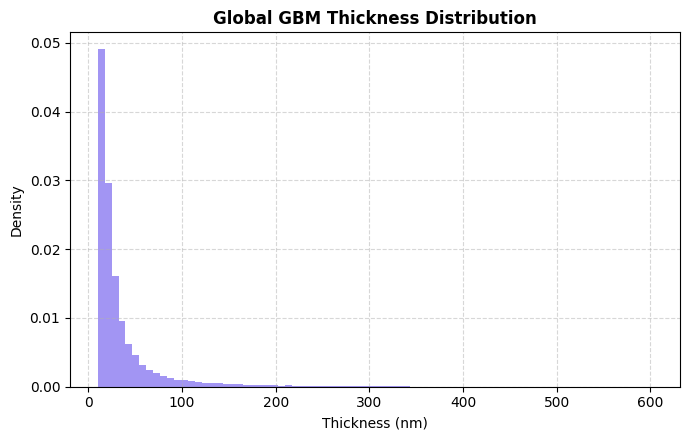

 Global distribution plot saved to:
   C:\Users\ishin\OneDrive\Desktop\Ishini\images\global_gbm_distribution.png


In [2]:
# %%
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import distance_transform_edt, binary_closing
from skimage.morphology import skeletonize

# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================

IMAGE_FOLDER = r"C:\Users\ishin\OneDrive\Desktop\Ishini\images"
OUTPUT_CSV = os.path.join(IMAGE_FOLDER, "gbm_thickness_results.csv")
OUTPUT_PLOT = os.path.join(IMAGE_FOLDER, "global_gbm_distribution.png")

# Exact scale factor calculated from TEM scale bar
NM_PER_PIXEL = 0.9901  

# Physical validation bounds in nm
MIN_VALID_NM = 10.0   
MAX_VALID_NM = 1500.0 

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def classify_thickness(mean_thickness):
    """
    Classifies mean GBM thickness based on biological standards (in nm).
    Normal human GBM ranges ~250-400 nm; diabetes typically leads to thickening (>450 nm).
    """
    if mean_thickness < 200.0:
        return "Thin"
    elif 200.0 <= mean_thickness <= 450.0:
        return "Normal"
    else:
        return "Thick"

def process_single_image(image_path):
    """Processes a single binary mask image to compute GBM orthogonal thickness."""
    filename = os.path.basename(image_path)
    
    # Extract Patient ID and Glomerulus ID from filename (e.g., "01-24_1g_01.tif")
    parts = filename.split('_')
    patient_id = parts[0] if len(parts) > 0 else "Unknown"
    glomerulus_id = parts[1] if len(parts) > 1 else "Unknown"  # Corrected index to 1
    
    # Load image as binary mask
    img = Image.open(image_path).convert('L')
    # Threshold foreground
    binary_mask = np.array(img) > 128  
    
    if not np.any(binary_mask):
        return []

    # Morphological cleanup
    cleaned_mask = binary_closing(binary_mask, structure=np.ones((3, 3)))
    
    # Distance Transform (calculates distance to nearest background pixel)
    dist_trans = distance_transform_edt(cleaned_mask)
    
    # Skeletonization (center-line of the membrane)
    skeleton = skeletonize(cleaned_mask)
    
    # Extract orthogonal thickness along the skeleton (2 * distance * scale)
    raw_thicknesses = dist_trans[skeleton] * 2.0 * NM_PER_PIXEL
    
    # Filter out extreme noise 
    valid_thicknesses = raw_thicknesses[
        (raw_thicknesses >= MIN_VALID_NM) & (raw_thicknesses <= MAX_VALID_NM)
    ]
    
    if len(valid_thicknesses) == 0:
        return []
        
    mean_thick = np.mean(valid_thicknesses)
    median_thick = np.median(valid_thicknesses)
    std_thick = np.std(valid_thicknesses)
    category = classify_thickness(mean_thick)
    
    # Return structured data record
    return [{
        "Filename": filename,
        "Patient_ID": patient_id,
        "Glomerulus": glomerulus_id,
        "Mean_Thickness_nm": mean_thick,
        "Median_Thickness_nm": median_thick,
        "Std_Dev_nm": std_thick,
        "Category": category,
        "Raw_Values": valid_thicknesses
    }]

# ==========================================
# 3. MAIN EXECUTION PIPELINE
# ==========================================
def main():
    print("Starting GBM Thickness Analysis Pipeline...")
    
    # Find all supported image formats in the updated folder
    search_pattern = os.path.join(IMAGE_FOLDER, "*.[tT][iI][fF]*")
    image_paths = glob.glob(search_pattern)
    
    if not image_paths:
        # Fallback to PNG if TIFs aren't found
        image_paths = glob.glob(os.path.join(IMAGE_FOLDER, "*.png"))

    print(f"Found {len(image_paths)} image file(s) in: {IMAGE_FOLDER}")
    
    all_results = []
    all_raw_thicknesses = []

    for path in image_paths:
        results = process_single_image(path)
        if results:
            all_results.extend(results)
            all_raw_thicknesses.extend(results[0]["Raw_Values"])
            print(f" Processed: {results[0]['Filename']} | Mean Thickness: {results[0]['Mean_Thickness_nm']:.2f} nm")

    if not all_results:
        print("No valid data processed. Please check image masks and path.")
        return

    # Convert results summary to DataFrame 
    df = pd.DataFrame(all_results)
    
    # Exclude heavy array column from CSV
    df_csv = df.drop(columns=["Raw_Values"]) 
    df_csv.to_csv(OUTPUT_CSV, index=False)
    print(f"\n Analysis results successfully saved to:\n   {OUTPUT_CSV}")

    # ==========================================
    # 4. GLOBAL HISTOGRAM GENERATION
    # ==========================================
    # Adjusted figsize to display properly inside Spyder inline console
    plt.figure(figsize=(7, 4.5))
    plt.hist(all_raw_thicknesses, bins=80, density=True, color='mediumslateblue', alpha=0.7, edgecolor='none')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.title("Global GBM Thickness Distribution", fontsize=12, fontweight='bold')
    plt.xlabel("Thickness (nm)", fontsize=10)
    plt.ylabel("Density", fontsize=10)
    plt.tight_layout()
    
    # Save high resolution figure separately
    plt.savefig(OUTPUT_PLOT, dpi=300)
    plt.show()
    print(f" Global distribution plot saved to:\n   {OUTPUT_PLOT}")

if __name__ == "__main__":
    main()